2025-03-14 18:04:05,017 - INFO - === Iniciando Optimizador de Pipelines para EEG ===
2025-03-14 18:04:05,018 - INFO - Cargando datos preprocesados...
2025-03-14 18:04:05,023 - INFO - Datos cargados: X shape (29, 51264), y shape (29,)
2025-03-14 18:04:05,023 - INFO - Clases: [1 2 3]
2025-03-14 18:04:05,024 - INFO - Iniciando evaluación de pipelines...
2025-03-14 18:04:05,025 - INFO - Creados 26 pipelines para evaluación
2025-03-14 18:04:05,026 - INFO - Evaluando pipeline: standard_pca_svc
2025-03-14 18:04:07,254 - INFO - standard_pca_svc: Accuracy = 0.3800 ± 0.1240, F1 = 0.3043 (Tiempo: 2.23s)
2025-03-14 18:04:07,255 - INFO - Evaluando pipeline: standard_pca_svc_linear
2025-03-14 18:04:08,412 - INFO - standard_pca_svc_linear: Accuracy = 0.5533 ± 0.1258, F1 = 0.5188 (Tiempo: 1.16s)
2025-03-14 18:04:08,413 - INFO - Evaluando pipeline: standard_pca_rf
2025-03-14 18:04:11,371 - INFO - standard_pca_rf: Accuracy = 0.5200 ± 0.1869, F1 = 0.4317 (Tiempo: 2.95s)
2025-03-14 18:04:11,372 - INFO - E

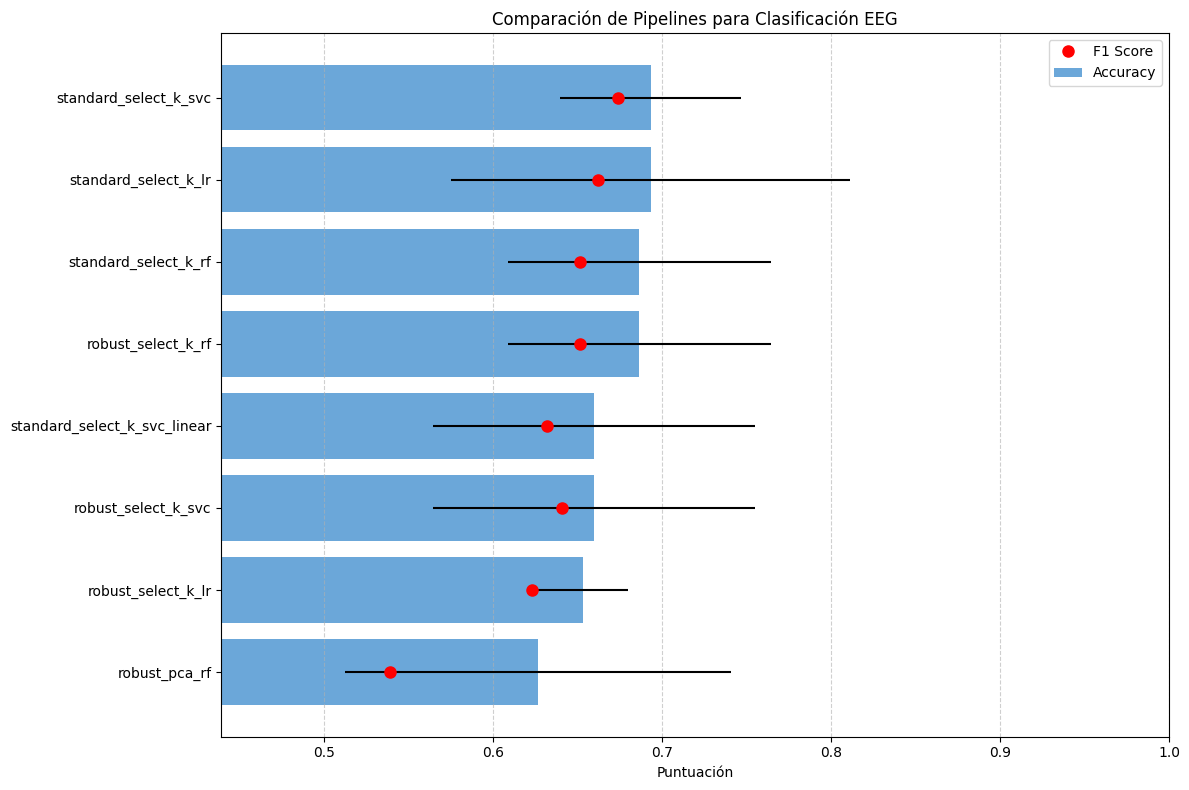

In [1]:
import numpy as np
import os
import json
import time
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score
from joblib import dump

# Configuración de logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('pipeline_optimizer')

# Directorio para guardar modelos
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)


def load_data(models_dir=MODELS_DIR):
    """
    Carga los datos preprocesados de EEG
    """
    logger.info("Cargando datos preprocesados...")
    
    # Buscar archivos preprocesados
    x_files = [f for f in os.listdir(models_dir) if f.startswith('X_preprocessed') and f.endswith('.npy')]
    y_files = [f for f in os.listdir(models_dir) if f.startswith('y_labels') and f.endswith('.npy')]
    
    if not x_files or not y_files:
        raise FileNotFoundError(f"No se encontraron archivos de datos en {models_dir}")
    
    # Ordenar por timestamp para obtener los más recientes
    x_files.sort(reverse=True)
    y_files.sort(reverse=True)
    
    X = np.load(os.path.join(models_dir, x_files[0]))
    y = np.load(os.path.join(models_dir, y_files[0]))
    
    logger.info(f"Datos cargados: X shape {X.shape}, y shape {y.shape}")
    logger.info(f"Clases: {np.unique(y)}")
    
    # Intentar cargar info de preprocesamiento
    preprocessing_info = None
    info_files = [f for f in os.listdir(models_dir) if f.startswith('preprocessing_info') and f.endswith('.json')]
    if info_files:
        info_files.sort(reverse=True)
        with open(os.path.join(models_dir, info_files[0]), 'r') as f:
            preprocessing_info = json.load(f)
    
    return X, y, preprocessing_info


def create_pipeline_combinations():
    """
    Crea una selección balanceada de pipelines para clasificación de EEG
    """
    # Componentes para los pipelines
    scalers = {
        'standard': StandardScaler(),
        'robust': RobustScaler()
    }
    
    feature_processors = {
        'pca': PCA(n_components=0.95),
        'pca_fixed': PCA(n_components=15),
        'select_k': SelectKBest(f_classif, k=20)
    }
    
    classifiers = {
        'svc': SVC(probability=True, class_weight='balanced', random_state=42),
        'svc_linear': SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42),
        'rf': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
        'lr': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    }
    
    # Crear combinaciones de pipelines
    pipelines = {}
    
    for scaler_name, scaler in scalers.items():
        for feat_name, feat_processor in feature_processors.items():
            for clf_name, clf in classifiers.items():
                pipeline_name = f"{scaler_name}_{feat_name}_{clf_name}"
                
                pipeline = Pipeline([
                    ('scaler', scaler),
                    ('feature_processor', feat_processor),
                    ('classifier', clf)
                ])
                
                pipelines[pipeline_name] = pipeline
    
    # Añadir pipelines personalizados de alto rendimiento
    custom_pipelines = {
        'optimized_svc': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95)),
            ('classifier', SVC(C=10, gamma='scale', kernel='rbf', probability=True, class_weight='balanced', random_state=42))
        ]),
        'optimized_rf': Pipeline([
            ('scaler', RobustScaler()),
            ('pca', PCA(n_components=20)),
            ('classifier', RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=2, class_weight='balanced', random_state=42))
        ])
    }
    
    pipelines.update(custom_pipelines)
    
    logger.info(f"Creados {len(pipelines)} pipelines para evaluación")
    return pipelines


def evaluate_pipelines(X, y, n_top=5):
    """
    Evalúa todos los pipelines y retorna los mejores
    """
    logger.info("Iniciando evaluación de pipelines...")
    
    # Crear pipelines
    pipelines = create_pipeline_combinations()
    
    # Configurar validación cruzada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Métricas para evaluación
    scoring = {
        'accuracy': 'accuracy',
        'f1_weighted': make_scorer(f1_score, average='weighted')
    }
    
    # Evaluar cada pipeline
    results = []
    
    for name, pipeline in pipelines.items():
        logger.info(f"Evaluando pipeline: {name}")
        
        try:
            start_time = time.time()
            
            # Evaluación con validación cruzada
            scores = cross_val_score(
                pipeline, X, y,
                cv=cv,
                scoring='accuracy',
                n_jobs=-1  # Usar todos los cores disponibles
            )
            
            # Métricas adicionales
            f1_scores = cross_val_score(
                pipeline, X, y,
                cv=cv,
                scoring=make_scorer(f1_score, average='weighted'),
                n_jobs=-1
            )
            
            # Tiempo y resultados
            eval_time = time.time() - start_time
            mean_acc = np.mean(scores)
            std_acc = np.std(scores)
            mean_f1 = np.mean(f1_scores)
            
            logger.info(f"{name}: Accuracy = {mean_acc:.4f} ± {std_acc:.4f}, F1 = {mean_f1:.4f} (Tiempo: {eval_time:.2f}s)")
            
            # Guardar resultados
            results.append({
                'name': name,
                'accuracy': float(mean_acc),
                'acc_std': float(std_acc),
                'f1_score': float(mean_f1),
                'time': float(eval_time),
                'pipeline': pipeline
            })
            
        except Exception as e:
            logger.error(f"Error evaluando {name}: {str(e)}")
    
    # Ordenar por accuracy
    results.sort(key=lambda x: x['accuracy'], reverse=True)
    
    # Mostrar los mejores pipelines
    logger.info(f"\nMejores {n_top} pipelines:")
    for i, result in enumerate(results[:n_top]):
        logger.info(f"{i+1}. {result['name']}: Accuracy = {result['accuracy']:.4f}, F1 = {result['f1_score']:.4f}")
    
    return results


def train_best_pipeline(results, X, y):
    """
    Entrena el mejor pipeline con todos los datos
    """
    if not results:
        logger.error("No hay resultados disponibles para entrenar el mejor pipeline")
        return None
    
    # Obtener el mejor pipeline
    best_result = results[0]
    best_pipeline_name = best_result['name']
    best_pipeline = best_result['pipeline']
    best_accuracy = best_result['accuracy']
    
    logger.info(f"\nEntrenando el mejor pipeline: {best_pipeline_name} (Accuracy: {best_accuracy:.4f})")
    
    # Entrenar con todos los datos
    start_time = time.time()
    best_pipeline.fit(X, y)
    training_time = time.time() - start_time
    
    # Guardar el pipeline entrenado
    pipeline_path = os.path.join(MODELS_DIR, 'best_eeg_pipeline.joblib')
    dump(best_pipeline, pipeline_path)
    
    # Guardar información
    pipeline_info = {
        'name': best_pipeline_name,
        'accuracy': float(best_accuracy),
        'training_time': float(training_time),
        'path': pipeline_path,
        'date': time.strftime('%Y-%m-%d %H:%M:%S')
    }
    
    info_path = os.path.join(MODELS_DIR, 'best_pipeline_info.json')
    with open(info_path, 'w') as f:
        json.dump(pipeline_info, f, indent=4)
    
    logger.info(f"Pipeline guardado en: {pipeline_path}")
    
    return best_pipeline, pipeline_info


def visualize_results(results, title="Comparación de Pipelines"):
    """
    Visualiza los resultados de evaluación
    """
    if not results:
        logger.error("No hay resultados para visualizar")
        return
    
    # Tomar los 8 mejores resultados para visualización
    top_results = results[:8]
    
    # Datos para gráfico
    names = [r['name'] for r in top_results]
    accuracies = [r['accuracy'] for r in top_results]
    f1_scores = [r['f1_score'] for r in top_results]
    std_errors = [r['acc_std'] for r in top_results]
    
    # Invertir orden para mejor visualización
    names = names[::-1]
    accuracies = accuracies[::-1]
    f1_scores = f1_scores[::-1]
    std_errors = std_errors[::-1]
    
    # Crear gráfico
    fig, ax = plt.figure(figsize=(12, 8)), plt.subplot(111)
    
    # Barras para accuracy
    ax.barh(range(len(names)), accuracies, xerr=std_errors, 
            align='center', alpha=0.7, color='#2C82C9', label='Accuracy')
    
    # Línea para F1 score
    for i, (name, f1) in enumerate(zip(names, f1_scores)):
        ax.plot(f1, i, 'ro', markersize=8, label='F1 Score' if i == 0 else "")
    
    # Formato
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel('Puntuación')
    ax.set_title(title)
    ax.set_xlim(min(min(accuracies)-0.1, min(f1_scores)-0.1), 1.0)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, 'pipeline_comparison.png'))
    logger.info(f"Gráfico guardado en: {os.path.join(MODELS_DIR, 'pipeline_comparison.png')}")


def main():
    """
    Función principal para encontrar el mejor pipeline de clasificación de EEG
    """
    logger.info("=== Iniciando Optimizador de Pipelines para EEG ===")
    
    try:
        # Cargar datos preprocesados
        X, y, preprocessing_info = load_data()
        
        # Evaluar pipelines
        results = evaluate_pipelines(X, y)
        
        if results:
            # Visualizar resultados
            visualize_results(results, "Comparación de Pipelines para Clasificación EEG")
            
            # Entrenar el mejor pipeline
            best_pipeline, pipeline_info = train_best_pipeline(results, X, y)
            
            # Resumen
            logger.info("\n=== Resumen de Optimización ===")
            logger.info(f"Mejor pipeline: {pipeline_info['name']}")
            logger.info(f"Accuracy: {pipeline_info['accuracy']:.4f}")
            logger.info(f"Tiempo de entrenamiento: {pipeline_info['training_time']:.2f} segundos")
            logger.info(f"Modelo guardado en: {pipeline_info['path']}")
            logger.info("==============================")
        else:
            logger.error("No se encontraron pipelines válidos")
            
    except Exception as e:
        logger.error(f"Error en el optimizador de pipelines: {str(e)}")
        raise


if __name__ == "__main__":
    main()
